# Augmentation Pipeline Demo

This notebook demonstrates how **text** and **labels** are transformed during GliZNet training using the `ZSHOT-HARDSET-v2` dataset.

**Label augmentation pipeline** (applied to candidate labels):
1. **RatioEnforcementSelector** — randomly picks between negative-heavy, positive-heavy, or pass-through distributions
2. **LabelLimit** — caps total labels, shuffles order, and replaces underscores

**Text augmentation pipeline** (applied to input text):
- Uses `nlpaug` augmenters: KeyboardTypo, OcrTypo, SpellingError, CharSwap, CharDrop, WordDrop
- Plus custom: SuffixTruncation, RandomCaseChange
- Each augmenter fires independently with a configured probability

In [1]:
import sys
sys.path.insert(0, "..")

import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from gliznet.augmentation import (
    load_augmentation_pipeline,
    load_label_augmentation_pipeline,
    RatioEnforcement,
    RatioEnforcementSelector,
    LabelLimit,
    LabelAugmentationPipeline,
    AugmentationPipeline,
    AUGMENTATION_REGISTRY,
)
from gliznet.data import load_dataset

random.seed(42)
np.random.seed(42)
print("Imports OK")

Imports OK


## 1. Load V2 Dataset Samples

Load a few samples from `alexneakameni/ZSHOT-HARDSET-v2` to see original label distributions.

In [2]:
ds = load_dataset("alexneakameni/ZSHOT-HARDSET-v2", split="train")
print(f"Dataset size: {len(ds)} samples")
print(f"Columns: {ds.column_names}")
print()

# Show 5 samples
for i in range(5):
    sample = ds[i]
    pos = sum(sample["lint"])
    neg = len(sample["lint"]) - pos
    print(f"Sample {i}: text='{sample['text'][:80]}...'")
    print(f"  Labels ({len(sample['ltext'])} total): {pos} positive, {neg} negative")
    print(f"  ltext: {sample['ltext'][:8]}{'...' if len(sample['ltext']) > 8 else ''}")
    print(f"  lint:  {sample['lint'][:8]}{'...' if len(sample['lint']) > 8 else ''}")
    print()

Dataset size: 392374 samples
Columns: ['text', 'ltext', 'lint']

Sample 0: text='Honestly, seeing how much education everyone in Mörschwil has is wild; it's like...'
  Labels (8 total): 4 positive, 4 negative
  ltext: ['statistical_observation', 'civic_comparison', 'policy_critique_implied', 'political_preference_reporting', 'educational_level_profiling', 'economic_indicator_analysis', 'casual_information_sharing', 'community_characteristic_assertion']
  lint:  [1, 0, 0, 0, 1, 0, 1, 1]

Sample 1: text='I wonder how the voting patterns in Mörschwil compare to bigger cities—it feels ...'
  Labels (8 total): 4 positive, 4 negative
  ltext: ['regional_comparison_context', 'socioeconomic_profile', 'political_preference_reporting', 'civic_comparison', 'demographic_snapshot', 'local_data_presentation', 'educational_level_profiling', 'informal_discussion']
  lint:  [1, 0, 1, 1, 0, 0, 0, 1]

Sample 2: text='The unemployment rate being so low there is seriously impressive, much better th...'
  L

## 2. RatioEnforcementSelector

This augmentation randomly selects between three modes:
- **Negative-heavy** (50% prob): keeps 1-3 positives and 3-10 negatives → simulates real-world imbalance
- **Positive-heavy** (20% prob): keeps 2-6 positives and 0-2 negatives → forces model to handle multi-label cases
- **Pass-through** (30% prob): keeps original distribution unchanged

In [3]:
ratio_selector = RatioEnforcementSelector(
    neg_prob=0.5,
    pos_prob=0.2,
    neg_params={"min_positives": 1, "max_positives": 3, "min_negatives": 3, "max_negatives": 10},
    pos_params={"min_positives": 2, "max_positives": 6, "min_negatives": 0, "max_negatives": 2},
)

# Show before/after for 5 samples
print("RatioEnforcementSelector — Before vs After\n" + "=" * 60)
for i in range(5):
    sample = ds[i]
    ltext, lint = sample["ltext"], sample["lint"]
    pos_before = sum(lint)
    neg_before = len(lint) - pos_before

    ltext_aug, lint_aug = ratio_selector(ltext.copy(), lint.copy())
    pos_after = sum(lint_aug)
    neg_after = len(lint_aug) - pos_after

    print(f"\nSample {i}:")
    print(f"  BEFORE: {pos_before} pos, {neg_before} neg (total {len(lint)})")
    print(f"  AFTER:  {pos_after} pos, {neg_after} neg (total {len(lint_aug)})")
    print(f"  Labels after: {ltext_aug[:6]}{'...' if len(ltext_aug) > 6 else ''}")

RatioEnforcementSelector — Before vs After

Sample 0:
  BEFORE: 4 pos, 4 neg (total 8)
  AFTER:  2 pos, 2 neg (total 4)
  Labels after: ['civic_comparison', 'community_characteristic_assertion', 'economic_indicator_analysis', 'educational_level_profiling']

Sample 1:
  BEFORE: 4 pos, 4 neg (total 8)
  AFTER:  1 pos, 3 neg (total 4)
  Labels after: ['informal_discussion', 'educational_level_profiling', 'local_data_presentation', 'socioeconomic_profile']

Sample 2:
  BEFORE: 4 pos, 4 neg (total 8)
  AFTER:  4 pos, 4 neg (total 8)
  Labels after: ['statistical_observation', 'demographic_snapshot', 'personal_reflection', 'casual_information_sharing', 'economic_indicator_analysis', 'local_data_presentation']...

Sample 3:
  BEFORE: 4 pos, 4 neg (total 8)
  AFTER:  1 pos, 4 neg (total 5)
  Labels after: ['socioeconomic_profile', 'informal_discussion', 'economic_indicator_analysis', 'educational_level_profiling', 'statistical_observation']

Sample 4:
  BEFORE: 4 pos, 4 neg (total 8)
  AFTER: 

## 3. LabelLimit

After ratio enforcement, `LabelLimit` applies:
- Caps total labels to `max_labels=20`
- Shuffles label order (randomizes position each epoch)
- Replaces underscores with spaces 90% of the time (`remove_underscores=0.9`)

In [4]:
label_limit = LabelLimit(max_labels=20, shuffle_labels=True, remove_underscores=0.9)

# Show before/after for a sample with underscores
sample = ds[0]
ltext, lint = sample["ltext"], sample["lint"]

# Inject some underscored labels for demo
ltext_demo = ltext.copy()
ltext_demo[0] = "machine_learning"
ltext_demo[1] = "natural_language_processing"

print("LabelLimit — Before vs After\n" + "=" * 60)
print(f"\nBEFORE ({len(ltext_demo)} labels):")
print(f"  ltext: {ltext_demo[:10]}...")
print(f"  lint:  {lint[:10]}...")

ltext_out, lint_out = label_limit(ltext_demo.copy(), lint.copy())
print(f"\nAFTER ({len(ltext_out)} labels):")
print(f"  ltext: {ltext_out[:10]}{'...' if len(ltext_out) > 10 else ''}")
print(f"  lint:  {lint_out[:10]}{'...' if len(lint_out) > 10 else ''}")
print(f"\n  Note: underscores replaced → 'machine_learning' becomes 'machine learning'")

LabelLimit — Before vs After

BEFORE (8 labels):
  ltext: ['machine_learning', 'natural_language_processing', 'policy_critique_implied', 'political_preference_reporting', 'educational_level_profiling', 'economic_indicator_analysis', 'casual_information_sharing', 'community_characteristic_assertion']...
  lint:  [1, 0, 0, 0, 1, 0, 1, 1]...

AFTER (5 labels):
  ltext: ['community characteristic assertion', 'political preference reporting', 'policy critique implied', 'casual information sharing', 'machine learning']
  lint:  [1, 0, 0, 1, 1]

  Note: underscores replaced → 'machine_learning' becomes 'machine learning'


## 4. Visualize Label Distribution Before and After

Compare positive/negative label counts across the dataset before and after the full pipeline.

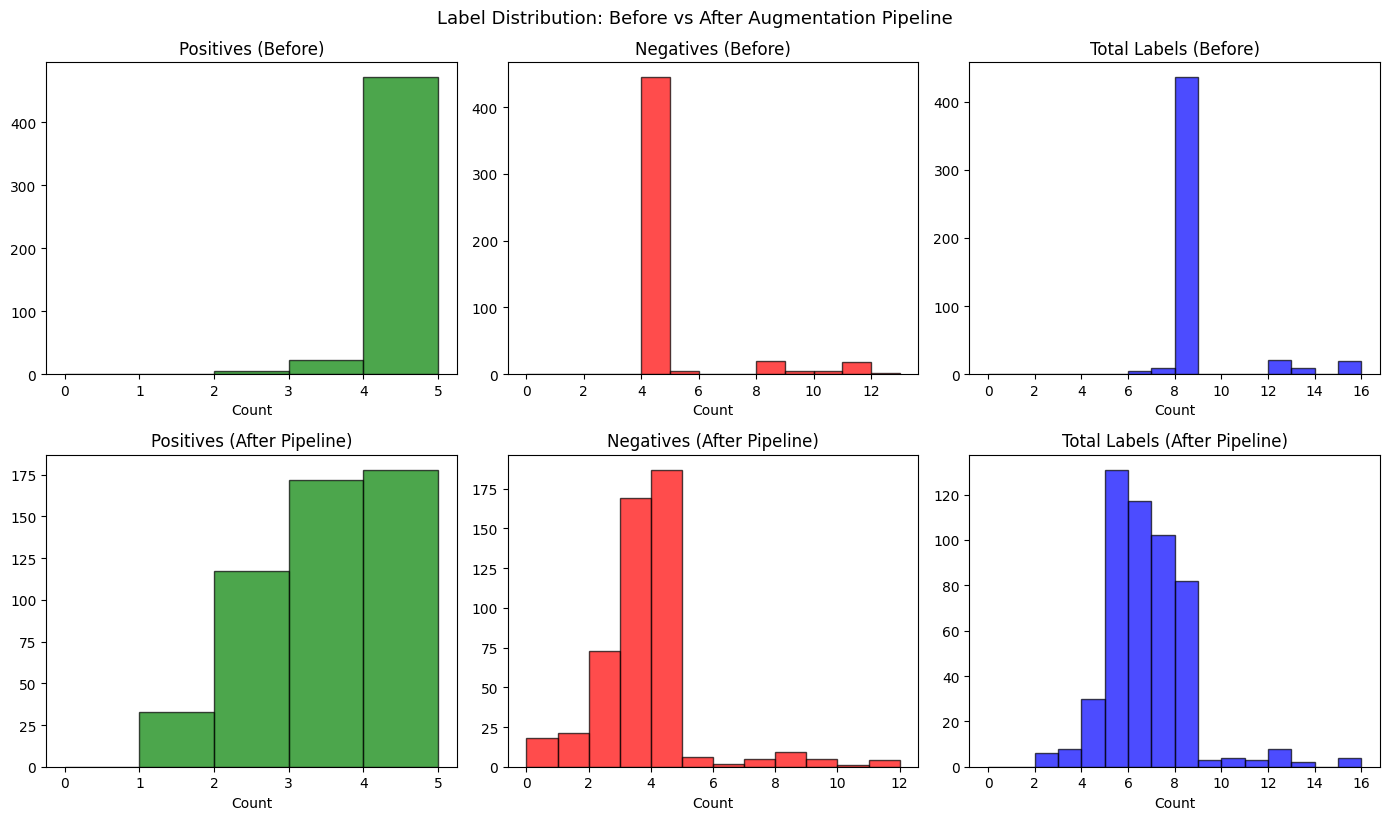

In [5]:
# Load full pipeline from config
pipeline = load_label_augmentation_pipeline("../config/augmentation_config.yaml")

N = min(500, len(ds))

# Collect stats before and after
pos_before, neg_before, total_before = [], [], []
pos_after, neg_after, total_after = [], [], []

for i in range(N):
    sample = ds[i]
    ltext, lint = sample["ltext"], sample["lint"]

    p = sum(lint)
    n = len(lint) - p
    pos_before.append(p)
    neg_before.append(n)
    total_before.append(len(lint))

    ltext_aug, lint_aug = pipeline(ltext.copy(), lint.copy())
    p2 = sum(lint_aug)
    n2 = len(lint_aug) - p2
    pos_after.append(p2)
    neg_after.append(n2)
    total_after.append(len(lint_aug))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Before
axes[0, 0].hist(pos_before, bins=range(0, max(pos_before) + 2), alpha=0.7, color="green", edgecolor="black")
axes[0, 0].set_title("Positives (Before)")
axes[0, 0].set_xlabel("Count")

axes[0, 1].hist(neg_before, bins=range(0, max(neg_before) + 2), alpha=0.7, color="red", edgecolor="black")
axes[0, 1].set_title("Negatives (Before)")
axes[0, 1].set_xlabel("Count")

axes[0, 2].hist(total_before, bins=range(0, max(total_before) + 2), alpha=0.7, color="blue", edgecolor="black")
axes[0, 2].set_title("Total Labels (Before)")
axes[0, 2].set_xlabel("Count")

# After
axes[1, 0].hist(pos_after, bins=range(0, max(pos_after) + 2), alpha=0.7, color="green", edgecolor="black")
axes[1, 0].set_title("Positives (After Pipeline)")
axes[1, 0].set_xlabel("Count")

axes[1, 1].hist(neg_after, bins=range(0, max(neg_after) + 2), alpha=0.7, color="red", edgecolor="black")
axes[1, 1].set_title("Negatives (After Pipeline)")
axes[1, 1].set_xlabel("Count")

axes[1, 2].hist(total_after, bins=range(0, max(total_after) + 2), alpha=0.7, color="blue", edgecolor="black")
axes[1, 2].set_title("Total Labels (After Pipeline)")
axes[1, 2].set_xlabel("Count")

plt.tight_layout()
plt.suptitle("Label Distribution: Before vs After Augmentation Pipeline", y=1.02, fontsize=13)
plt.show()

## 5. Full Pipeline Statistics on Batch

Run the full label augmentation pipeline on 500+ samples and report summary statistics.

In [6]:
print(f"Summary over {N} samples\n" + "=" * 50)
print(f"\n{'Metric':<25} {'Before':>10} {'After':>10}")
print("-" * 50)
print(f"{'Mean positives':<25} {np.mean(pos_before):>10.2f} {np.mean(pos_after):>10.2f}")
print(f"{'Mean negatives':<25} {np.mean(neg_before):>10.2f} {np.mean(neg_after):>10.2f}")
print(f"{'Mean total labels':<25} {np.mean(total_before):>10.2f} {np.mean(total_after):>10.2f}")
print(f"{'Median positives':<25} {np.median(pos_before):>10.1f} {np.median(pos_after):>10.1f}")
print(f"{'Median negatives':<25} {np.median(neg_before):>10.1f} {np.median(neg_after):>10.1f}")
print(f"{'Max total labels':<25} {max(total_before):>10} {max(total_after):>10}")
print(f"{'All-positive samples':<25} {sum(1 for n in neg_before if n == 0):>10} {sum(1 for n in neg_after if n == 0):>10}")
print(f"{'All-negative samples':<25} {sum(1 for p in pos_before if p == 0):>10} {sum(1 for p in pos_after if p == 0):>10}")

# Pos/Neg ratio distribution
ratios_after = [p / max(n, 1) for p, n in zip(pos_after, neg_after)]
print(f"\n{'Mean pos/neg ratio':<25} {'':>10} {np.mean(ratios_after):>10.2f}")
print(f"{'Std pos/neg ratio':<25} {'':>10} {np.std(ratios_after):>10.2f}")

Summary over 500 samples

Metric                        Before      After
--------------------------------------------------
Mean positives                  3.93       2.99
Mean negatives                  4.56       3.34
Mean total labels               8.50       6.33
Median positives                 4.0        3.0
Median negatives                 4.0        3.0
Max total labels                  15         15
All-positive samples               0         18
All-negative samples               0          0

Mean pos/neg ratio                         1.11
Std pos/neg ratio                          0.79


---
# Text Augmentation

The text augmentation pipeline introduces subtle noise to simulate real-world typos and informal writing. Each augmenter fires independently with low probability to avoid destroying the text.

Available augmenters (from `config/augmentation_config.yaml`):

| Name | Type | Description |
|------|------|-------------|
| SuffixTruncation | custom | "running" → "runnin" |
| RandomCaseChange | custom | Lowercase capitals |
| KeyboardTypo | nlpaug | QWERTY adjacent key errors |
| OcrTypo | nlpaug | OCR-like substitutions |
| SpellingError | nlpaug | Common misspellings |
| RandomChar(swap) | nlpaug | Adjacent character swap |
| RandomChar(delete) | nlpaug | Delete a character |
| RandomWord(delete) | nlpaug | Delete random words |

## 6. Individual Text Augmenters

Show each augmenter in isolation on a sample text.

In [7]:
sample_text = ds[0]["text"]
print(f"Original:\n  {sample_text}\n")

# Each entry: (registry_name, params for demo visibility)
augmenters = [
    ("SuffixTruncation", {"word_prob": 0.3}),
    ("RandomCaseChange", {"word_prob": 0.3}),
    ("KeyboardTypo", {"aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("OcrTypo", {"aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("SpellingError", {"aug_p": 0.3, "aug_min": 1}),
    ("RandomChar", {"action": "swap", "aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("RandomChar", {"action": "delete", "aug_word_p": 0.3, "aug_char_min": 1, "aug_char_max": 1, "min_char": 4}),
    ("RandomWord", {"action": "delete", "aug_p": 0.3, "aug_min": 1}),
]

for name, params in augmenters:
    aug = AUGMENTATION_REGISTRY[name](**params)
    result = aug(sample_text)
    label = f"{name}({params.get('action', '')})" if "action" in params else name
    print(f"{label}:")
    print(f"  {result}\n")

Original:
  Honestly, seeing how much education everyone in Mörschwil has is wild; it's like a super smart town.

SuffixTruncation:
  Honestly, seeing how much education everyone in Mörschwil has is wild; it's like a super smart town.

RandomCaseChange:
  honestly, seeing how much education everyone in Mörschwil has is wild; it's like a super smart town.

KeyboardTypo:
  HonestlT, seeing how muVh educat9on everyone in MörscJwil has is wild; it ' s like a supee sJart towm.

OcrTypo:
  Honest1y, seeing how moch educati0n everyune in Mökschwil has is wi1d; it ' s like a soper smart town.

SpellingError:
  Honeslty, seeing who match education eveyone in Mörschwil has is wind; it ' s lile a surper smart town.

RandomChar(swap):
  Honsetly, seenig how much educatoin everoyne in Ömrschwil has is wild; it ' s like a suepr samrt town.

RandomChar(delete):
  Honestly, eeing how mch ducation everyoe in Mörschwl has is wild; it ' s ike a super smart ton.

RandomWord(delete):
  Honestly, how much i

## 7. Full Text Augmentation Pipeline

Load the pipeline from config and apply it to dataset samples. Each augmenter fires independently with its configured probability — most of the time only 1-2 augmenters trigger per sample.

In [8]:
text_pipeline = load_augmentation_pipeline("../config/augmentation_config.yaml")
print(f"Pipeline: {text_pipeline}\n")

# Show 10 samples: original vs augmented
print("Text Augmentation — Before vs After\n" + "=" * 80)
for i in range(10):
    original = ds[i]["text"]
    augmented = text_pipeline(original)
    changed = original != augmented
    print(f"\nSample {i} {'[CHANGED]' if changed else '[UNCHANGED]'}:")
    print(f"  Original:  {original[:100]}{'...' if len(original) > 100 else ''}")
    print(f"  Augmented: {augmented[:100]}{'...' if len(augmented) > 100 else ''}")

Pipeline: AugmentationPipeline([(0.1, SuffixTruncation()), (0.15, KeyboardTypo()), (0.1, OcrTypo()), (0.1, SpellingError()), (0.1, RandomChar()), (0.15, RandomChar()), (0.1, RandomWord()), (0.15, RandomCaseChange())])

Text Augmentation — Before vs After

Sample 0 [UNCHANGED]:
  Original:  Honestly, seeing how much education everyone in Mörschwil has is wild; it's like a super smart town.
  Augmented: Honestly, seeing how much education everyone in Mörschwil has is wild; it's like a super smart town.

Sample 1 [UNCHANGED]:
  Original:  I wonder how the voting patterns in Mörschwil compare to bigger cities—it feels really specific to t...
  Augmented: I wonder how the voting patterns in Mörschwil compare to bigger cities—it feels really specific to t...

Sample 2 [CHANGED]:
  Original:  The unemployment rate being so low there is seriously impressive, much better than what I see elsewh...
  Augmented: The unemp1oyment rate bein9 so low there is seriously impressive, much than what I see

## 8. Text Augmentation Statistics

Measure how often text is modified and by how much (edit distance) across a batch of samples.

Texts modified: 106/200 (53.0%)
Avg similarity (SequenceMatcher): 0.947
Min similarity: 0.054


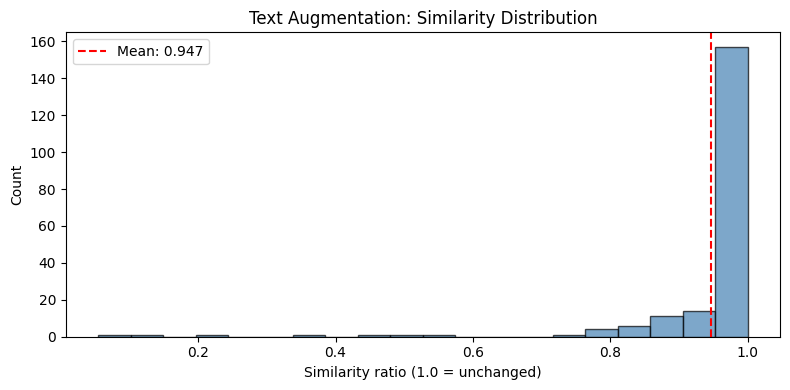

In [9]:
from difflib import SequenceMatcher

N_text = 200
change_count = 0
ratios = []  # similarity ratios

for i in range(N_text):
    original = ds[i]["text"]
    augmented = text_pipeline(original)
    if original != augmented:
        change_count += 1
    ratio = SequenceMatcher(None, original, augmented).ratio()
    ratios.append(ratio)

print(f"Texts modified: {change_count}/{N_text} ({100*change_count/N_text:.1f}%)")
print(f"Avg similarity (SequenceMatcher): {np.mean(ratios):.3f}")
print(f"Min similarity: {np.min(ratios):.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratios, bins=20, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(np.mean(ratios), color="red", linestyle="--", label=f"Mean: {np.mean(ratios):.3f}")
ax.set_xlabel("Similarity ratio (1.0 = unchanged)")
ax.set_ylabel("Count")
ax.set_title("Text Augmentation: Similarity Distribution")
ax.legend()
plt.tight_layout()
plt.show()